In [ ]:
# Random Forest Classifier for Loan Default Prediction

# loads all required libraries and custom functions needed for data processing, model training, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

import warnings
warnings.filterwarnings('ignore')

# Add src folder to path for custom modules
sys.path.append('../src')
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from utils import load_processed_data, get_features_and_target, plot_feature_importance, print_dataset_info

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Load preprocessed data

# Load all processed datasets using utils
datasets = load_processed_data()

# Get features and target for training data (SMOTE balanced)
X_train, y_train = get_features_and_target(datasets['train'])

# Get features and target for test data
X_test, y_test = get_features_and_target(datasets['test'])

# Print dataset info
print_dataset_info(datasets['train'], 'Training Set (SMOTE)')
print_dataset_info(datasets['test'], 'Test Set')


Training Set (SMOTE) Information
Shape: (14188, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'Default']

Target distribution:
Default
1    7094
0    7094
Name: count, dtype: int64

Test Set Information
Shape: (2000, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', '

In [ ]:
# Baseline Random Forest Model (Class-Balanced)

#rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced') # Use class_weight='balanced' to handle class imbalance (we dont use both balanced and smote because smote is already balanced)
#trained wihtout balanced because we have already balanced the data using smote
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight=None) # Train without class_weight='balanced' since we have already balanced the data using SMOTE
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]

print("Baseline Random Forest (class_weight=None) trained!")#evaluate baseline model without balanced class weight since we have already balanced the data using SMOTE

Baseline Random Forest (class_weight=None) trained!



Random Forest (Baseline) Evaluation Results
ACCURACY    : 0.8780
PRECISION   : 0.3509
RECALL      : 0.0881
F1_SCORE    : 0.1408
AUC_ROC     : 0.7044

Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.98      0.93      1773
     Default       0.35      0.09      0.14       227

    accuracy                           0.88      2000
   macro avg       0.62      0.53      0.54      2000
weighted avg       0.83      0.88      0.84      2000



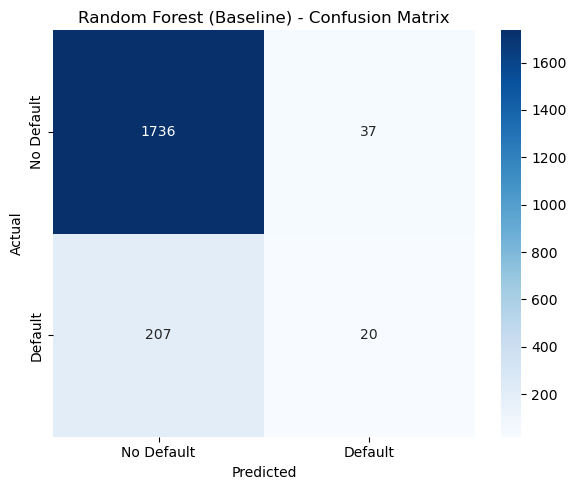

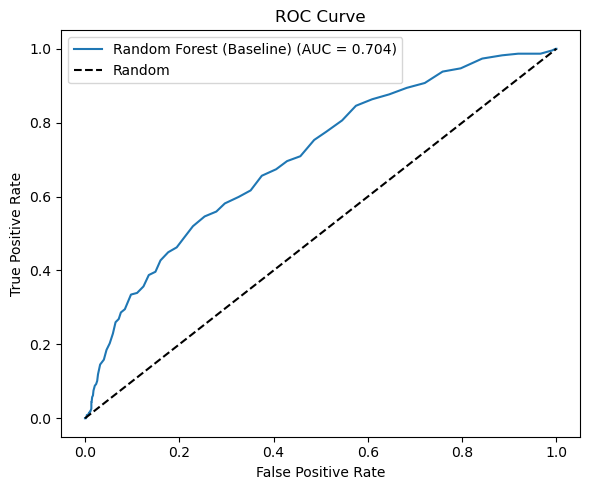

0.7044134856921369

In [ ]:
# Evaluate Baseline Model

baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_prob_baseline, 'Random Forest (Baseline)')
plot_confusion_matrix(y_test, y_pred_baseline, 'Random Forest (Baseline)')
plot_roc_curve(y_test, y_prob_baseline, 'Random Forest (Baseline)')

In [ ]:
# Faster Hyperparameter Tuning (Randomized Search + Class Balance)

param_distributions = {
    'n_estimators': [100, 200, 300, 400], #n_estimators -> number of trees in the forest
    'max_depth': [10, 20, 30, None], #max_depth -> how deep each tree can grow
    'min_samples_split': [2, 5, 10], #min_samples_split -> minimum samples needed to split a node
    'min_samples_leaf': [1, 2, 4], #min_samples_leaf -> minimum samples allowed in a final leaf
    'max_features': ['sqrt', 'log2', None] #max_features -> how many features each tree considers at a split
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight=None  # Train without class_weight='balanced' since we have already balanced the data using SMOTE
)
# Randomly test 30 combinations of parameters, use 3-fold cross-validation, and choose the one with the best F1-score.
grid_search = RandomizedSearchCV(
    estimator=rf, #estimator -> the model to tune (our Random Forest)
    param_distributions=param_distributions, #param_distributions -> hyperparameters and candidate values
    n_iter=30, #n_iter=30 -> test 30 random parameter combinations
    cv=3, #cv=3 -> split training data into 3 parts for validation
    scoring='f1', #scoring='f1' -> choose the model with the best F1-score
    n_jobs=-1, #n_jobs=-1 -> run faster using all CPU cores
    random_state=42, #random_state=42 -> ensure reproducible results
    verbose=1 #verbose=1 -> print progress during tuning
)

print("Starting RandomizedSearchCV... (optimized for minority-class recall)")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV Recall score: {grid_search.best_score_:.4f}")

Starting RandomizedSearchCV... (optimized for minority-class recall)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Recall score: 0.9317


Best Threshold: 0.34
Best F1-Score: 0.3210



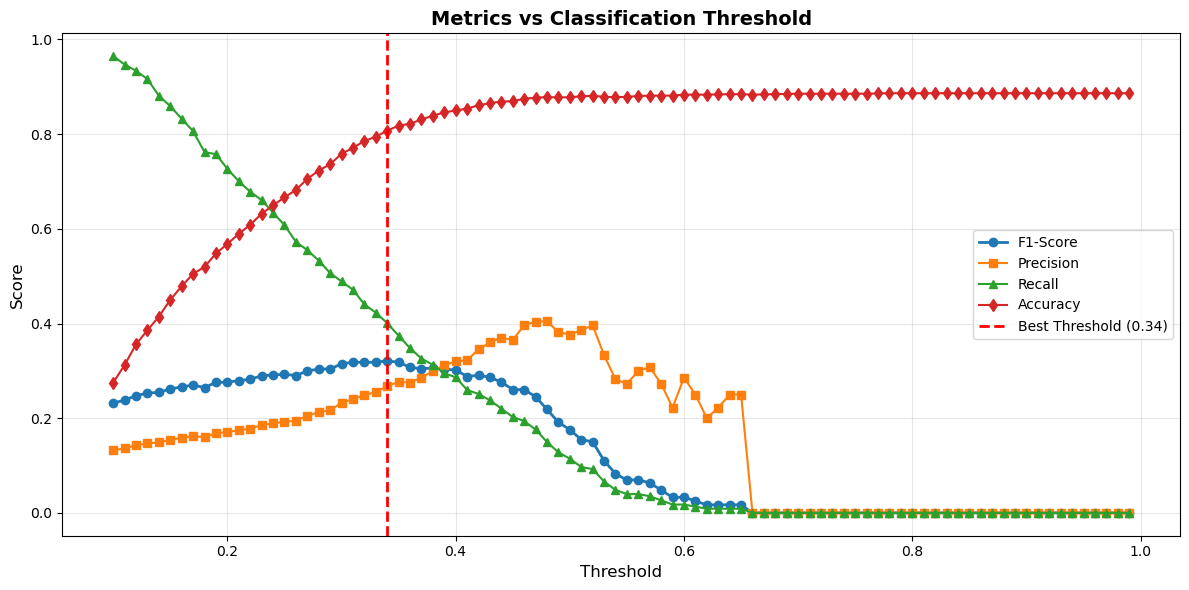


Evaluation at Best Threshold (0.34):
threshold    0.340000
f1           0.320988
precision    0.267647
recall       0.400881
accuracy     0.807500
Name: 24, dtype: float64

Random Forest (Tuned, threshold=0.34) Evaluation Results
ACCURACY    : 0.8075
PRECISION   : 0.2676
RECALL      : 0.4009
F1_SCORE    : 0.3210
AUC_ROC     : 0.7093

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      0.86      0.89      1773
     Default       0.27      0.40      0.32       227

    accuracy                           0.81      2000
   macro avg       0.59      0.63      0.60      2000
weighted avg       0.84      0.81      0.82      2000



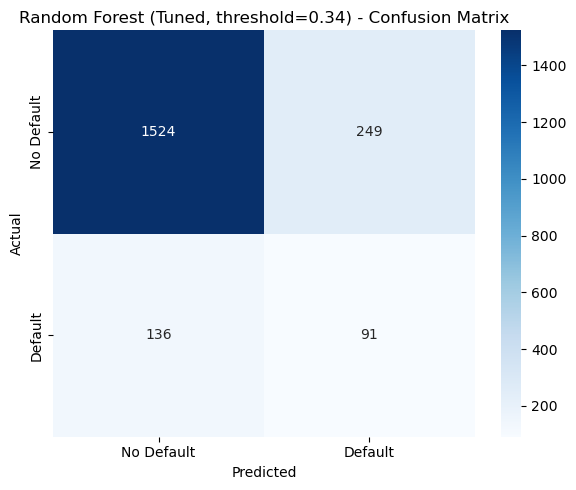

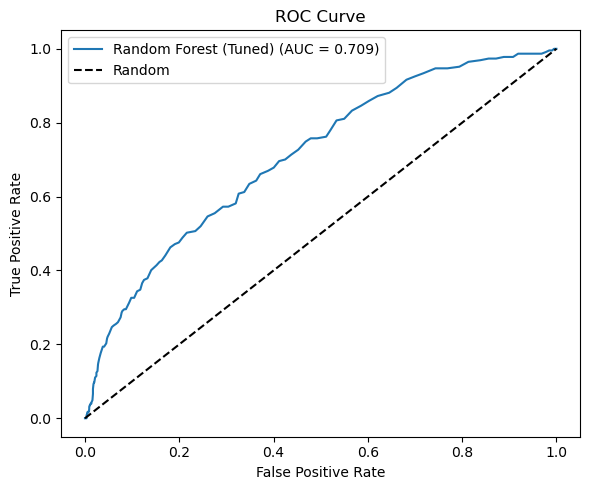

0.7092535859726541

In [ ]:
# Evaluate Tuned Model (Automatic Threshold Optimization)

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

rf_tuned = grid_search.best_estimator_

# Predicted probabilities for class 1 (Default)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# Test thresholds from 0.1 to 0.9 in increments of 0.01
thresholds = np.arange(0.1, 1.0, 0.01)
results = []

for threshold in thresholds:
    y_pred = (y_prob_tuned >= threshold).astype(int)
    
    results.append({
        'threshold': threshold,
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# Find best threshold based on F1-score
best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1']

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-Score: {best_f1:.4f}\n")

# Plot threshold vs metrics
plt.figure(figsize=(12, 6))
plt.plot(results_df['threshold'], results_df['f1'], label='F1-Score', marker='o', linewidth=2)
plt.plot(results_df['threshold'], results_df['precision'], label='Precision', marker='s')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall', marker='^')
plt.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', marker='d')

plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})', linewidth=2)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate model with best threshold
print(f"\nEvaluation at Best Threshold ({best_threshold:.2f}):")
print("=" * 50)
print(results_df.loc[best_idx])
y_pred_best = (y_prob_tuned >= best_threshold).astype(int)
tuned_metrics = evaluate_model(y_test, y_pred_best, y_prob_tuned, f'Random Forest (Tuned, threshold={best_threshold:.2f})')

plot_confusion_matrix(y_test, y_pred_best, f'Random Forest (Tuned, threshold={best_threshold:.2f})')
plot_roc_curve(y_test, y_prob_tuned, 'Random Forest (Tuned)')


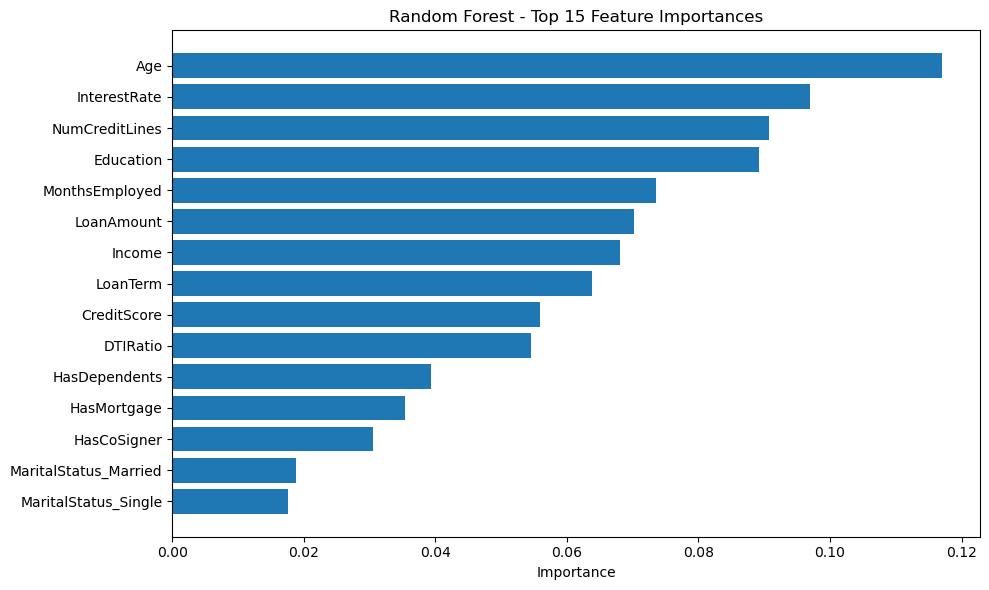


Top 10 Most Important Features:
       feature  importance
           Age    0.116958
  InterestRate    0.096943
NumCreditLines    0.090681
     Education    0.089244
MonthsEmployed    0.073534
    LoanAmount    0.070245
        Income    0.068009
      LoanTerm    0.063794
   CreditScore    0.055879
      DTIRatio    0.054602


In [ ]:
# Feature Importance

# Use utils function to plot and get feature importance
feature_importance = plot_feature_importance(
    feature_names=X_train.columns,
    importances=rf_tuned.feature_importances_,
    top_n=15,
    title='Random Forest - Top 15 Feature Importances'
)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [ ]:
# Model Comparison: Baseline vs Tuned
from evaluation import compare_models

results = {
    'RF Baseline': baseline_metrics,
    'RF Tuned': tuned_metrics
}

comparison_df = compare_models(results)


Model Comparison
             accuracy  precision  recall  f1_score  auc_roc
RF Baseline    0.8780     0.3509  0.0881    0.1408   0.7044
RF Tuned       0.8075     0.2676  0.4009    0.3210   0.7093


In [ ]:
# Save Best Model and Evaluation Outputs
import os
import json
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create folders if they do not exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# 1. Save tuned model
joblib.dump(rf_tuned, '../models/random_forest_tuned.pkl')

# 2. Save feature importance
feature_importance.to_csv('../results/rf_feature_importance.csv', index=False)

# 3. Save tuned metrics summary
metrics_df = pd.DataFrame([tuned_metrics])
metrics_df['model'] = 'Random Forest (Tuned)'
metrics_df.to_csv('../results/rf_metrics.csv', index=False)

# 4. Save classification report as text
report_text = classification_report(y_test, y_pred_best)
with open('../results/rf_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write("Random Forest (Tuned) - Classification Report\n")
    f.write("=============================================\n\n")
    f.write(report_text)

# 5. Save confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(
    cm,
    index=['Actual_0', 'Actual_1'],
    columns=['Predicted_0', 'Predicted_1']
 )
cm_df.to_csv('../results/rf_confusion_matrix.csv')

# 6. Save threshold and ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_tuned)

threshold_info = {
    'best_threshold': float(best_threshold),
    'roc_auc': float(roc_auc)
}
with open('../results/rf_threshold_auc.json', 'w', encoding='utf-8') as f:
    json.dump(threshold_info, f, indent=4)

# 7. Save best hyperparameters
with open('../results/rf_best_params.json', 'w', encoding='utf-8') as f:
    json.dump(grid_search.best_params_, f, indent=4)

# 8. Save baseline vs tuned comparison if available
comparison_data = []
if 'baseline_metrics' in globals():
    baseline_row = baseline_metrics.copy()
    baseline_row['model'] = 'Random Forest (Baseline)'
    comparison_data.append(baseline_row)

tuned_row = tuned_metrics.copy()
tuned_row['model'] = 'Random Forest (Tuned)'
comparison_data.append(tuned_row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('../results/rf_model_comparison.csv', index=False)

print("Model and results saved successfully!")
print("- Model: ../models/random_forest_tuned.pkl")
print("- Feature importance: ../results/rf_feature_importance.csv")
print("- Metrics: ../results/rf_metrics.csv")
print("- Classification report: ../results/rf_classification_report.txt")
print("- Confusion matrix: ../results/rf_confusion_matrix.csv")
print("- Threshold and ROC-AUC: ../results/rf_threshold_auc.json")
print("- Best hyperparameters: ../results/rf_best_params.json")
print("- Baseline vs tuned comparison: ../results/rf_model_comparison.csv")

Model and results saved successfully!
- Model: ../models/random_forest_tuned.pkl
- Feature importance: ../results/rf_feature_importance.csv
- Metrics: ../results/rf_metrics.csv
- Classification report: ../results/rf_classification_report.txt
- Confusion matrix: ../results/rf_confusion_matrix.csv
- Threshold and ROC-AUC: ../results/rf_threshold_auc.json
- Best hyperparameters: ../results/rf_best_params.json
- Baseline vs tuned comparison: ../results/rf_model_comparison.csv
